# Load libraries

In [1]:
suppressMessages(library("data.table"))
suppressMessages(library("withr"))
suppressMessages(library("ggplot2"))
suppressMessages(library("farver"))
suppressMessages(library("labeling"))
suppressMessages(library("optparse"))
suppressMessages(library("dplyr"))
suppressMessages(library("withr"))
suppressMessages(library("backports"))
suppressMessages(library("broom"))
suppressMessages(library("rstudioapi"))
suppressMessages(library("tzdb"))
suppressMessages(library("svglite"))
suppressMessages(library("ggeasy"))
suppressMessages(library("tidyverse"))
suppressMessages(library("BiocGenerics"))
suppressMessages(library("S4Vectors"))
suppressMessages(library("IRanges"))
suppressMessages(library("GenomeInfoDb"))
suppressMessages(library("GenomicRanges"))
suppressMessages(library("Biobase"))
suppressMessages(library("AnnotationDbi"))
suppressMessages(library("GO.db"))
suppressMessages(library("org.Hs.eg.db"))
suppressMessages(library("ggrepel"))
suppressMessages(library("RColorBrewer"))
suppressMessages(library("svglite"))
suppressMessages(library("cowplot"))
suppressMessages(library("Matrix"))
suppressMessages(library("rtracklayer"))
suppressMessages(library("Biostrings"))
suppressMessages(library("ggrepel"))
suppressMessages(library("ggnewscale"))
suppressMessages(library("splitstackshape"))
suppressMessages(library("viridis"))
suppressMessages(library("viridis"))
suppressMessages(library("ggsci"))
suppressMessages(library("plyr"))
suppressMessages(library("ggupset"))
suppressMessages(library("patchwork"))
suppressMessages(library("ggh4x"))
suppressMessages(library("ComplexHeatmap"))
suppressMessages(library("tidyr"))
suppressMessages(library("circlize"))
suppressMessages(library("grid"))
suppressMessages(library("ggrepel"))
suppressMessages(library("cluster"))
suppressMessages(library("clusterProfiler"))
suppressMessages(library("projectStyleR"))
suppressMessages(library("scales"))
suppressMessages(library(patchwork))
suppressMessages(library(igraph))
suppressMessages(library(ggraph))


## Load palettes

In [2]:
palettes_path <- system.file("palettes.yaml", package = "projectStyleR")
themes_path <- system.file("themes.yaml", package = "projectStyleR")
palettes <- yaml::read_yaml(palettes_path)
themes <- yaml::read_yaml(themes_path)
available_palettes()
available_themes()


Available palettes:

 - primary

 - vibrant

 - muted_tones

Available themes:

 - default

 - publication



# PATH

**v3**: output directory changed to `Patterns_in_factors_refined/` to keep this run separate from the prior version.

In [3]:
outdir <- "/nfs/team151/mt19/overhaul_classification_factors_with_programs/Patterns_in_factors_refined/"
dir.create(outdir, recursive = TRUE, showWarnings = FALSE)
cat("Created:", outdir, "\n")


Created: /nfs/team151/mt19/overhaul_classification_factors_with_programs/Patterns_in_factors_refined/ 


# Read in files

In [4]:
indir <- "/nfs/team151/mt19/annotation_preprocessed/"


## literature_review

In [5]:
literature_review <- fread(file.path(indir, "literature_review_table.tsv"), sep = "\t")
cat("literature_review\n")
cat(str(literature_review))
cat("\n")


Warning message in fread(file.path(indir, "literature_review_table.tsv"), sep = "\t"):
“Stopped early on line 231. Expected 13 fields but found 12. Consider fill=TRUE and comment.char=. First discarded non-empty line: <<STRING_PPI_lenient	Within	full	lenient (hub, expanded)	Undirected (Arbitrary)	S100A4	CD48, RAP1B	NK_CD16, NK_CD56bright, T_CD4_CTL	Not individually searched; another S100-family member, same co-packaging caveat as S100A8/9/12 plausible	S100 family granule/membrane biology	Not verified, same caveat as other S100 pairs	NA>>”


literature_review
Classes ‘data.table’ and 'data.frame':	229 obs. of  13 variables:
 $ dataset           : chr  "STRING_PPI_strict" "STRING_PPI_strict" "STRING_PPI_strict" "STRING_PPI_strict" ...
 $ edge_type         : chr  "Within" "Within" "Within" "Within" ...
 $ graph             : chr  "GWAS_colocalized" "GWAS_colocalized" "GWAS_colocalized" "GWAS_colocalized" ...
 $ stringency        : chr  "strict" "strict" "strict" "strict" ...
 $ directionality    : chr  "Undirected (Arbitrary)" "Undirected (Arbitrary)" "Undirected (Arbitrary)" "Undirected (Arbitrary)" ...
 $ partner1          : chr  "NFKB1" "NFKB1" "PLEC" "CD300LB" ...
 $ partner2          : chr  "ETS1" "ETS1" "VIM" "CD300A" ...
 $ cell_type_s       : chr  "T_CD4_naive, T_CD8_naive" "T_CD4_naive, T_CD8_naive" "T_CD8_EMRA" "NK_CD16" ...
 $ gwas_trait_s      : chr  "allergic rhinitis, deep vein thrombosis, lymphocyte count" "allergic rhinitis, deep vein thrombosis, lymphocyte count" "platelet crit" "C-reactive protein measureme

## LIVI_names

In [6]:
LIVI_names <- fread(file.path(indir, "UKBB_eQTLs_LIVI_custom_loci_colocalization_table_factors-annotated.tsv"), sep = "\t")
cat("LIVI_names\n")
cat(str(LIVI_names))
cat("\n")


LIVI_names
Classes ‘data.table’ and 'data.frame':	27271 obs. of  22 variables:
 $ nsnps                    : int  6400 6400 6400 6400 6400 6400 8896 8896 8896 8896 ...
 $ PP.H0.abf                : num  2.72e-11 2.72e-11 2.72e-11 2.72e-11 2.72e-11 ...
 $ PP.H1.abf                : num  6.29e-11 6.29e-11 6.29e-11 6.29e-11 6.29e-11 ...
 $ PP.H2.abf                : num  0.0121 0.0121 0.0121 0.0121 0.0121 ...
 $ PP.H3.abf                : num  0.027 0.027 0.027 0.027 0.027 ...
 $ PP.H4.abf                : num  0.961 0.961 0.961 0.961 0.961 ...
 $ t1_study_id              : chr  "UKBB_cardinal_danais_embeddings_specific_loci" "UKBB_cardinal_danais_embeddings_specific_loci" "UKBB_cardinal_danais_embeddings_specific_loci" "UKBB_cardinal_danais_embeddings_specific_loci" ...
 $ t1                       : chr  "D_Factor286" "D_Factor286" "D_Factor286" "D_Factor286" ...
 $ t2_study_id              : chr  "UKBB_cardinal" "UKBB_cardinal" "UKBB_cardinal" "UKBB_cardinal" ...
 $ t2                  

## Annotated graph

In [7]:
whole_eqtl_annotated <- readRDS(file = "/nfs/team151/mt19/overhaul_classification_factors_with_programs/whole_eqtl_annotated.rds")
cat("whole_eqtl_annotated\n")
cat(str(whole_eqtl_annotated))
cat("\n")


whole_eqtl_annotated
Classes ‘data.table’ and 'data.frame':	305496 obs. of  14 variables:
 $ Source_trait         : chr  "T_CD4_naive:ENSG00000103145" "T_CD4_naive:ENSG00000103145" "T_CD4_naive:ENSG00000103145" "T_CD4_naive:ENSG00000103145" ...
 $ Target_trait         : chr  "T_CD4_naive:ENSG00000185885" "T_CD4_naive:ENSG00000117984" "T_CD4_naive:ENSG00000175390" "T_CD4_naive:ENSG00000090554" ...
 $ program              : chr  "D_Factor36" "D_Factor36" "D_Factor36" "D_Factor36" ...
 $ Source_cell          : chr  "T_CD4_naive" "T_CD4_naive" "T_CD4_naive" "T_CD4_naive" ...
 $ Source_gene          : chr  "ENSG00000103145" "ENSG00000103145" "ENSG00000103145" "ENSG00000103145" ...
 $ Target_cell          : chr  "T_CD4_naive" "T_CD4_naive" "T_CD4_naive" "T_CD4_naive" ...
 $ Target_gene          : chr  "ENSG00000185885" "ENSG00000117984" "ENSG00000175390" "ENSG00000090554" ...
 $ Source_module        : chr  "M_10" "M_10" "M_10" "M_10" ...
 $ edge.type            : chr  "Within" "Within" "With

# Map ENSG to symbols

Not persisted in `whole_eqtl_annotated.rds` - recomputed live in every session
that needs it, with a fallback to ALIAS for IDs not covered by the primary
SYMBOL mapping, and a final fallback to the raw Ensembl ID for anything still
unmapped (rather than leaving `NA`, which would break `build_factor_graph()`'s
node-naming downstream).

In [8]:
all_ensg <- unique(c(whole_eqtl_annotated$Source_gene, whole_eqtl_annotated$Target_gene))
cat("Unique Ensembl gene IDs to map:", length(all_ensg), "\n")

primary_map <- suppressWarnings(mapIds(org.Hs.eg.db, keys = all_ensg,
                                        column = "SYMBOL", keytype = "ENSEMBL", multiVals = "first"))
unmapped_ids <- names(primary_map)[is.na(primary_map)]

valid_ensembl_keys <- keys(org.Hs.eg.db, keytype = "ENSEMBL")
alias_eligible_ids <- intersect(unmapped_ids, valid_ensembl_keys)

if (length(alias_eligible_ids) > 0) {
  alias_map <- suppressWarnings(mapIds(org.Hs.eg.db, keys = alias_eligible_ids,
                                        column = "ALIAS", keytype = "ENSEMBL", multiVals = "first"))
} else {
  alias_map <- character(0)
}

ensg2symbol <- primary_map
still_missing <- names(alias_map)[!is.na(alias_map)]
ensg2symbol[still_missing] <- alias_map[still_missing]

cat("Total unmapped after alias fallback:", sum(is.na(ensg2symbol)), "/", length(all_ensg), "\n")

whole_eqtl_annotated[, Source_symbol := ensg2symbol[Source_gene]]
whole_eqtl_annotated[, Target_symbol := ensg2symbol[Target_gene]]
whole_eqtl_annotated[is.na(Source_symbol), Source_symbol := Source_gene]
whole_eqtl_annotated[is.na(Target_symbol), Target_symbol := Target_gene]

known_check <- c("ENSG00000136997" = "MYC", "ENSG00000109320" = "NFKB1", "ENSG00000177606" = "JUN")
for (ensg in names(known_check)) {
  cat(sprintf("Check: %s -> mapped '%s' (expected '%s') %s\n",
              ensg, ensg2symbol[[ensg]], known_check[[ensg]],
              ifelse(identical(unname(ensg2symbol[[ensg]]), known_check[[ensg]]), "OK", "MISMATCH")))
}


Unique Ensembl gene IDs to map: 3143 


'select()' returned 1:many mapping between keys and columns



Total unmapped after alias fallback: 132 / 3143 
Check: ENSG00000136997 -> mapped 'MYC' (expected 'MYC') OK
Check: ENSG00000109320 -> mapped 'NFKB1' (expected 'NFKB1') OK
Check: ENSG00000177606 -> mapped 'JUN' (expected 'JUN') OK


# === Resource colors / annotation parsing helpers ===

In [9]:
resource_colors <- c(
  "STRING_experimental" = palettes$vibrant$blue,
  "CollecTRI"            = palettes$vibrant$vermillion,
  "Liana"                = palettes$vibrant$green,
  "POSTAR3"              = palettes$vibrant$magenta,
  "MEROPS"                = palettes$vibrant$yellow
)
edge_colors <- c(resource_colors, "No annotation" = "grey70")

known_resource_names <- c("STRING_experimental", "CollecTRI", "Liana", "POSTAR3", "MEROPS")

extract_resource_name <- function(resource_str) {
  for (r in known_resource_names) if (startsWith(resource_str, r)) return(r)
  NA_character_
}

classify_direction <- function(role_str) {
  if (startsWith(role_str, "PPI")) return("undirected")
  if (grepl("^Source_.*->Target", role_str)) return("forward")
  if (grepl("^Target_.*->Source", role_str)) return("reverse")
  NA_character_
}


# === Load CollecTRI strict (needed for generic cascade detection, used by EVERY pattern) ===

In [10]:
collectri_strict <- fread("/nfs/team151/mt19/annotation_preprocessed/collectri_strict.tsv")
stopifnot(all(collectri_strict$partner1_role == "TF"))
stopifnot(all(collectri_strict$partner2_role == "TF_target"))
stopifnot(all(collectri_strict$resource_name == "CollecTRI"))
stopifnot(all(collectri_strict$stringency == "strict"))

tf_genes_generic <- unique(collectri_strict$partner1_ensembl_gene_id)
tf_target_pairs <- collectri_strict[, .(TF_gene = partner1_ensembl_gene_id, target_gene = partner2_ensembl_gene_id)]

cat("n unique TF genes in CollecTRI strict:", length(tf_genes_generic), "\n")
cat("n TF->target pairs available for cascade detection:", nrow(tf_target_pairs), "\n")


n unique TF genes in CollecTRI strict: 800 
n TF->target pairs available for cascade detection: 15463 


# === Graph-building function (base hub-and-spoke, no cascade) ===

In [11]:
build_factor_graph <- function(unit_data) {
  hub_symbol <- unique(unit_data$Source_symbol)
  stopifnot(length(hub_symbol) == 1)

  spokes <- unique(unit_data[, .(Target_gene, Target_symbol)])

  base_edges <- data.table(
    from = hub_symbol, to = spokes$Target_symbol,
    edge_label = "No annotation", is_arrow = FALSE, ppi_band = NA_character_
  )

  annot_rows <- unit_data[!is.na(edge_role)]
  annot_edges_list <- list()
  if (nrow(annot_rows) > 0) {
    for (i in seq_len(nrow(annot_rows))) {
      roles     <- strsplit(annot_rows$edge_role[i], ";")[[1]]
      resources <- strsplit(annot_rows$edge_resource[i], ";")[[1]]
      stopifnot(length(roles) == length(resources))
      for (j in seq_along(roles)) {
        res_name <- extract_resource_name(resources[j])
        dir_type <- classify_direction(roles[j])
        stopifnot(!is.na(res_name), !is.na(dir_type))

        ppi_band <- if (res_name == "STRING_experimental") {
          if (grepl(">=0.1 <0.4", roles[j], fixed = TRUE)) "weak" else
          if (grepl(">=0.4", roles[j], fixed = TRUE)) "strong" else NA_character_
        } else NA_character_

        if (dir_type == "forward") {
          annot_edges_list[[length(annot_edges_list) + 1]] <- data.table(
            from = hub_symbol, to = annot_rows$Target_symbol[i],
            edge_label = res_name, is_arrow = TRUE, ppi_band = ppi_band
          )
        } else if (dir_type == "reverse") {
          annot_edges_list[[length(annot_edges_list) + 1]] <- data.table(
            from = annot_rows$Target_symbol[i], to = hub_symbol,
            edge_label = res_name, is_arrow = TRUE, ppi_band = ppi_band
          )
        } else {
          annot_edges_list[[length(annot_edges_list) + 1]] <- data.table(
            from = hub_symbol, to = annot_rows$Target_symbol[i],
            edge_label = res_name, is_arrow = FALSE, ppi_band = ppi_band
          )
        }
      }
    }
  }
  annot_edges <- if (length(annot_edges_list) > 0) rbindlist(annot_edges_list) else
    data.table(from = character(0), to = character(0), edge_label = character(0),
               is_arrow = logical(0), ppi_band = character(0))

  all_edges <- rbind(base_edges, annot_edges)
  all_edges[, edge_width_cat := fifelse(!is.na(ppi_band) & ppi_band == "strong", "STRING score \u22650.4",
                                  fifelse(!is.na(ppi_band) & ppi_band == "weak",  "STRING score 0.1\u20130.4",
                                                                                  "other"))]
  all_edges[, edge_width_cat := factor(edge_width_cat,
                                        levels = c("other", "STRING score 0.1\u20130.4", "STRING score \u22650.4"))]
  all_edges[, is_cascade := FALSE]

  node_names <- unique(c(hub_symbol, spokes$Target_symbol))
  g <- graph_from_data_frame(all_edges, vertices = data.table(name = node_names), directed = TRUE)
  V(g)$is_hub <- V(g)$name == hub_symbol
  g
}


# === Generic cascade detection (applies to ANY unit_data/graph, ANY pattern) ===

Scans every pair of spoke genes actually present in the graph for a CollecTRI
TF->target relationship between them (in either direction), regardless of
which pattern or resource originally selected this unit. The hub gene is
excluded from cascade candidates - a hub<->spoke TF relationship is already
captured by `build_factor_graph()`'s own Source_TF->Target / Target_TF->Source
edges, so including it here would duplicate that edge under a different label.

Returns the graph with cascade edges added (or unchanged if none found), with
`n_cascade_edges` attached as a graph attribute.

In [12]:
add_cascade_edges_generic <- function(g, unit_data) {
  hub_gene   <- unique(unit_data$Source_gene)
  hub_symbol <- unique(unit_data$Source_symbol)

  spoke_gene_map <- unique(unit_data[, .(Target_gene, Target_symbol)])
  spoke_gene_map <- spoke_gene_map[Target_gene != hub_gene]

  candidate_pairs <- tf_target_pairs[
    TF_gene %in% spoke_gene_map$Target_gene & target_gene %in% spoke_gene_map$Target_gene
  ]

  edge_df <- as.data.table(as_data_frame(g, what = "edges"))
  if (!"is_cascade" %in% names(edge_df)) edge_df[, is_cascade := FALSE]
  edge_df[, edge_width_cat := as.character(edge_width_cat)]

  node_names <- V(g)$name
  level_set <- c("other", "STRING score 0.1\u20130.4", "STRING score \u22650.4")

  if (nrow(candidate_pairs) == 0) {
    edge_df[, edge_width_cat := factor(edge_width_cat, levels = level_set)]
    g2 <- graph_from_data_frame(edge_df, vertices = data.table(name = node_names), directed = TRUE)
    V(g2)$is_hub <- V(g2)$name == hub_symbol
    g2 <- set_graph_attr(g2, "n_cascade_edges", 0L)
    return(g2)
  }

  from_symbol <- spoke_gene_map$Target_symbol[match(candidate_pairs$TF_gene, spoke_gene_map$Target_gene)]
  to_symbol   <- spoke_gene_map$Target_symbol[match(candidate_pairs$target_gene, spoke_gene_map$Target_gene)]

  cascade_edges <- data.table(
    from = from_symbol, to = to_symbol,
    edge_label = "CollecTRI", is_arrow = TRUE, ppi_band = NA_character_,
    edge_width_cat = "other", is_cascade = TRUE
  )
  cascade_edges <- unique(cascade_edges[from != to])

  all_edges <- rbind(edge_df, cascade_edges, fill = TRUE)
  all_edges[, edge_width_cat := factor(edge_width_cat, levels = level_set)]

  stopifnot(all(c(cascade_edges$from, cascade_edges$to) %in% node_names))

  g2 <- graph_from_data_frame(all_edges, vertices = data.table(name = node_names), directed = TRUE)
  V(g2)$is_hub <- V(g2)$name == hub_symbol
  g2 <- set_graph_attr(g2, "n_cascade_edges", nrow(cascade_edges))
  g2
}


# === v3: split visualization - description graph + topology graph ===

Two views per unit, sharing an identical node layout so they can be visually
cross-referenced directly:

- **Description graph**: every node labeled by gene symbol, only the grey
  hub-spoke edges shown (no annotation colors/arrows) - gives a full, honest
  picture of how many trans-eQTL targets exist, even at the cost of dense
  labeling for large hubs.
- **Topology graph**: ONLY annotated/cascade edges are drawn; unannotated
  nodes are omitted from rendering entirely (via `filter=`, not literal
  `color=NA`/`fill=NA` - functionally identical outcome: the node's position
  in the shared layout is preserved so cascade edges connecting two spokes
  still route through the correct location, it is simply not drawn or
  labeled). This isolates the interesting structure from the clutter.

`compute_fixed_layout()` and `prepare_graph_attrs()` are called once per
graph and shared between both plotting functions, guaranteeing the two
views are spatially consistent.

In [13]:
compute_fixed_layout <- function(g, spoke_order = NULL) {
  hub_idx <- which(V(g)$is_hub)
  spoke_idx <- which(!V(g)$is_hub)

  # If no explicit order given, use current node order (unchanged behavior).
  # Later: pass spoke_order = order(-effect_size) to sort descending.
  ordered_spoke_idx <- if (is.null(spoke_order)) spoke_idx else spoke_idx[spoke_order]

  n_spokes <- length(spoke_idx)
  angles <- seq(0, 2 * pi, length.out = n_spokes + 1)[1:n_spokes]
  layout_mat <- matrix(0, nrow = vcount(g), ncol = 2)
  layout_mat[hub_idx, ] <- c(0, 0)
  layout_mat[ordered_spoke_idx, ] <- cbind(cos(angles), sin(angles))
  layout_mat
}

# --- Curvature computed ONCE across the full edge set, stored as E(g)$curvature ---
prepare_graph_attrs <- function(g, layout_mat) {
  V(g)$point_size <- ifelse(V(g)$is_hub, 8, 3)
  V(g)$label_size <- ifelse(V(g)$is_hub, 4, 3)
  V(g)$label_face <- ifelse(V(g)$is_hub, "bold", "plain")

  edge_df <- as_data_frame(g, what = "edges")
  annotated_edges <- edge_df[edge_df$edge_label != "No annotation", ]
  annotated_node_names <- unique(c(annotated_edges$from, annotated_edges$to))
  V(g)$show_topology <- V(g)$is_hub | (V(g)$name %in% annotated_node_names)

  node_pos <- data.table(name = V(g)$name, x = layout_mat[, 1], y = layout_mat[, 2])

  edge_dt <- as.data.table(edge_df)

  # --- Non-cascade edges: straight by default, small spread only for multi-edge pairs ---
  nc <- edge_dt[is_cascade == FALSE]
  nc[, pair_key := paste(pmin(from, to), pmax(from, to))]
  nc[, canonical_dir := from < to]
  nc[, edge_idx := seq_len(.N), by = pair_key]
  nc[, n_in_pair := .N, by = pair_key]
  nc[, base_curv := fifelse(n_in_pair == 1, 0, (edge_idx - (n_in_pair + 1) / 2) * 0.3)]
  nc[, curvature := fifelse(canonical_dir, base_curv, -base_curv)]

  # --- Cascade edges: always curved, bulging AWAY from the origin (outside the inner circle) ---
  cc <- edge_dt[is_cascade == TRUE]
  if (nrow(cc) > 0) {
    cc <- merge(cc, node_pos, by.x = "from", by.y = "name", all.x = TRUE)
    setnames(cc, c("x", "y"), c("x0", "y0"))
    cc <- merge(cc, node_pos, by.x = "to", by.y = "name", all.x = TRUE)
    setnames(cc, c("x", "y"), c("x1", "y1"))

    cc[, `:=`(dx = x1 - x0, dy = y1 - y0, mx = (x0 + x1) / 2, my = (y0 + y1) / 2)]
    cc[, `:=`(nx = -dy, ny = dx)]
    cc[, mnorm := sqrt(mx^2 + my^2)]
    cc[, `:=`(ox = fifelse(mnorm > 0, mx / mnorm, 1), oy = fifelse(mnorm > 0, my / mnorm, 0))]
    cc[, outward_sign := sign(nx * ox + ny * oy)]
    cc[outward_sign == 0, outward_sign := 1]
    cc[, curvature := outward_sign * 0.45]
    cc <- cc[, .(from, to, curvature)]
    cc <- merge(edge_dt[is_cascade == TRUE], cc, by = c("from", "to"))
  } else {
    cc <- edge_dt[is_cascade == TRUE][, curvature := numeric(0)]
  }

  final_edges <- rbind(nc, cc, fill = TRUE)
  final_edges <- final_edges[match(paste(edge_dt$from, edge_dt$to, edge_dt$edge_label, edge_dt$is_cascade),
                                    paste(final_edges$from, final_edges$to, final_edges$edge_label, final_edges$is_cascade))]

  E(g)$curvature <- round(final_edges$curvature, 3)
  g
}

# --- One geom_edge_arc layer per distinct curvature value present in the subset.
#     NOTE: uses strength=, not curvature= (curvature was renamed/deprecated
#     in ggraph >= 2.0.0 - this is the actual argument name in current versions). ---
add_curved_edge_layers <- function(p, edge_data, subset_expr, arrow_spec = NULL, alpha_val = 0.85) {
  subset_data <- edge_data[eval(subset_expr, edge_data)]
  if (nrow(subset_data) == 0) return(p)
  curv_values <- sort(unique(subset_data$curvature))
  for (cv in curv_values) {
    layer_filter <- substitute(base_filter & curvature == cv_val, list(base_filter = subset_expr, cv_val = cv))
    if (is.null(arrow_spec)) {
      p <- p + geom_edge_arc(aes(filter = !!layer_filter, color = edge_label, width = edge_width_cat),
                              alpha = alpha_val, strength = cv)
    } else {
      p <- p + geom_edge_arc(aes(filter = !!layer_filter, color = edge_label, width = edge_width_cat),
                              arrow = arrow_spec$arrow, start_cap = arrow_spec$start_cap, end_cap = arrow_spec$end_cap,
                              linetype = arrow_spec$linetype, alpha = alpha_val, strength = cv)
    }
  }
  p
}

plot_graph_description <- function(g, layout_mat, title_text) {
  ggraph(g, layout = layout_mat) +
    geom_edge_link(aes(filter = edge_label == "No annotation"),
                    color = "grey70", width = 0.5, alpha = 0.6) +
    geom_node_point(aes(size = point_size, filter = !show_topology),
                     fill = "grey85", shape = 21, stroke = 0.3, color = "grey60", alpha = 0.6) +
    geom_node_point(aes(size = point_size, filter = show_topology),
                     fill = "grey90", shape = 21, stroke = 0.6, color = "grey20") +
    geom_node_text(aes(label = name, size = label_size, fontface = label_face, filter = show_topology),
                    repel = TRUE, max.overlaps = Inf) +
    scale_size_identity() +
    labs(title = paste0(title_text, " \u2014 description")) +
    theme_void(base_size = 9) +
    theme(plot.title = element_text(size = 10, face = "bold"))
}

plot_graph_topology <- function(g, layout_mat, title_text) {
  edge_data <- as.data.table(as_data_frame(g, what = "edges"))
  p <- ggraph(g, layout = layout_mat)

  p <- add_curved_edge_layers(p, edge_data, quote(edge_label != "No annotation" & !is_arrow), alpha_val = 0.85)
  p <- add_curved_edge_layers(p, edge_data, quote(edge_label != "No annotation" & is_arrow & !is_cascade),
                               arrow_spec = list(arrow = arrow(length = unit(2.2, "mm"), type = "closed"),
                                                  start_cap = circle(3, "mm"), end_cap = circle(3, "mm"),
                                                  linetype = "solid"),
                               alpha_val = 0.85)
  p <- add_curved_edge_layers(p, edge_data, quote(edge_label != "No annotation" & is_arrow & is_cascade),
                               arrow_spec = list(arrow = arrow(length = unit(1.8, "mm"), type = "closed"),
                                                  start_cap = circle(3, "mm"), end_cap = circle(3, "mm"),
                                                  linetype = "dashed"),
                               alpha_val = 0.45)

  p <- p +
    geom_node_point(aes(size = point_size, filter = show_topology), fill = "grey90", shape = 21,
                     stroke = 0.6, color = "grey20") +
    geom_node_text(aes(label = name, size = label_size, fontface = label_face, filter = show_topology),
                    repel = TRUE) +
    scale_edge_color_manual(values = edge_colors, name = "Annotation") +
    scale_edge_width_manual(
      values = c("other" = 0.4, "STRING score 0.1\u20130.4" = 0.6, "STRING score \u22650.4" = 1.4),
      name = "PPI evidence strength",
      breaks = c("STRING score 0.1\u20130.4", "STRING score \u22650.4"),
      guide = guide_legend(override.aes = list(edge_colour = palettes$vibrant$blue))
    ) +
    scale_size_identity() +
    labs(title = paste0(title_text, " \u2014 topology"),
         caption = "Dashed arrow = TF also regulates a sibling trans-eQTL target (cascade)") +
    theme_void(base_size = 9) +
    theme(legend.position = "right", plot.title = element_text(size = 10, face = "bold"),
          plot.caption = element_text(size = 7, hjust = 0))
  p
}

# === Reusable batch-render functions (v3: produce BOTH description + topology per unit) ===

Both `_cascade` filename flagging (only when that unit actually has >=1
cascade edge) and the dual description/topology output apply uniformly here.

In [14]:
render_pattern_batch <- function(units_dt, pattern_dir) {
  dir.create(pattern_dir, recursive = TRUE, showWarnings = FALSE)
  manifest <- list()

  for (i in seq_len(nrow(units_dt))) {
    u <- units_dt[i]
    unit_data <- whole_eqtl_annotated[
      Source_module == u$Source_module &
      Source_gene   == u$Source_gene &
      program       == u$program &
      Source_cell   == u$Source_cell
    ]

    g <- build_factor_graph(unit_data)
    g <- add_cascade_edges_generic(g, unit_data)
    n_cascade <- graph_attr(g, "n_cascade_edges")
    has_cascade <- n_cascade > 0

    layout_mat <- compute_fixed_layout(g)          # layout FIRST
    g <- prepare_graph_attrs(g, layout_mat)         # then attrs, using that layout

    title_text <- paste(u$Source_module, u$Source_symbol, u$program, u$Source_cell, sep = " | ")
    file_base  <- gsub("[^A-Za-z0-9_.-]", "_", paste(u$Source_module, u$Source_symbol, u$program, u$Source_cell, sep = "_"))
    if (has_cascade) file_base <- paste0(file_base, "_cascade")

    p_desc <- plot_graph_description(g, layout_mat, title_text)
    p_topo <- plot_graph_topology(g, layout_mat, title_text)

    n_edges_this <- nrow(unit_data)
    w <- 8 + min(4, n_edges_this / 100)
    h <- 6 + min(3, n_edges_this / 150)

    for (sp in list(list(s = "description", p = p_desc), list(s = "topology", p = p_topo))) {
      fb <- paste0(file_base, "_", sp$s)
      ggsave(filename = paste0(pattern_dir, fb, ".pdf"), plot = sp$p, device = "pdf", width = w, height = h, bg = "white")
      ggsave(filename = paste0(pattern_dir, fb, ".png"), plot = sp$p, device = "png", width = w, height = h, dpi = 150, bg = "white")
      ggsave(filename = paste0(pattern_dir, fb, ".svg"), plot = sp$p, device = "svg", width = w, height = h, bg = "white")
    }

    cat(sprintf("[%d/%d] Saved %s (description + topology; n_edges=%d, n_annotated=%d, n_cascade_edges=%d)\n",
                i, nrow(units_dt), file_base, n_edges_this, sum(!is.na(unit_data$edge_role)), n_cascade))

    manifest[[i]] <- data.table(Source_module = u$Source_module, Source_symbol = u$Source_symbol,
                                 program = u$program, Source_cell = u$Source_cell, file_base = file_base,
                                 n_edges = n_edges_this, n_annotated = sum(!is.na(unit_data$edge_role)),
                                 n_cascade_edges = n_cascade, has_cascade = has_cascade)
  }
  manifest_dt <- rbindlist(manifest)
  fwrite(manifest_dt, paste0(pattern_dir, "manifest.tsv"), sep = "\t")
  manifest_dt
}

build_filename_target_cells <- function(target_cells_vec, max_listed = 4) {
  if (length(target_cells_vec) <= max_listed) {
    paste(target_cells_vec, collapse = "_")
  } else {
    paste0(paste(target_cells_vec[1:max_listed], collapse = "_"),
           "_and_", length(target_cells_vec) - max_listed, "_more")
  }
}

render_pattern_batch_small_multiples <- function(units_dt, full_pattern_data, pattern_dir) {
  dir.create(pattern_dir, recursive = TRUE, showWarnings = FALSE)
  manifest <- list()

  for (i in seq_len(nrow(units_dt))) {
    u <- units_dt[i]
    unit_full <- full_pattern_data[
      Source_module == u$Source_module & Source_gene == u$Source_gene &
      program       == u$program       & Source_cell == u$Source_cell
    ]
    target_cells_this <- sort(unique(unit_full$Target_cell))

    desc_plots <- list(); topo_plots <- list()
    any_cascade <- FALSE; total_cascade_edges <- 0

    for (tc in target_cells_this) {
      sub_data <- unit_full[Target_cell == tc]
      g <- build_factor_graph(sub_data)
      g <- add_cascade_edges_generic(g, sub_data)
      n_cascade_this_panel <- graph_attr(g, "n_cascade_edges")
      if (n_cascade_this_panel > 0) { any_cascade <- TRUE; total_cascade_edges <- total_cascade_edges + n_cascade_this_panel }

      layout_mat <- compute_fixed_layout(g)          # layout FIRST
      g <- prepare_graph_attrs(g, layout_mat)         # then attrs, using that layout

      # Panel title includes source-side context (symbol, program, source cell)
      # so a single extracted panel remains self-identifying
      panel_title <- paste0(u$Source_symbol, " (", u$program, ", ", u$Source_cell, ") \u2192 ", tc)

      desc_plots[[tc]] <- plot_graph_description(g, layout_mat, panel_title) +
        theme(plot.title = element_text(size = 8, face = "italic"))
      topo_plots[[tc]] <- plot_graph_topology(g, layout_mat, panel_title) +
        theme(plot.title = element_text(size = 8, face = "italic"))
    }

    ncol_layout <- ceiling(sqrt(length(desc_plots)))
    overall_title <- paste(u$Source_module, u$Source_symbol, u$program, u$Source_cell, sep = " | ")

    combined_desc <- wrap_plots(desc_plots, ncol = ncol_layout) +
      plot_annotation(title = paste0(overall_title, " \u2014 description"),
                       theme = theme(plot.title = element_text(size = 12, face = "bold")))
    combined_topo <- wrap_plots(topo_plots, ncol = ncol_layout) + plot_layout(guides = "collect") +
      plot_annotation(title = paste0(overall_title, " \u2014 topology"),
                       theme = theme(plot.title = element_text(size = 12, face = "bold")))

    file_base <- gsub("[^A-Za-z0-9_.-]", "_",
      paste0(u$Source_module, "_", u$Source_symbol, "_", u$program, "_", u$Source_cell,
             "_to_", build_filename_target_cells(target_cells_this)))
    if (any_cascade) file_base <- paste0(file_base, "_cascade")

    n_edges_this <- nrow(unit_full)
    w <- 5 * ncol_layout
    h <- 4 * ceiling(length(desc_plots) / ncol_layout) + 1

    for (sp in list(list(s = "description", p = combined_desc), list(s = "topology", p = combined_topo))) {
      fb <- paste0(file_base, "_", sp$s)
      ggsave(filename = paste0(pattern_dir, fb, ".pdf"), plot = sp$p, device = "pdf", width = w, height = h, limitsize = FALSE, bg = "white")
      ggsave(filename = paste0(pattern_dir, fb, ".png"), plot = sp$p, device = "png", width = w, height = h, dpi = 150, limitsize = FALSE, bg = "white")
      ggsave(filename = paste0(pattern_dir, fb, ".svg"), plot = sp$p, device = "svg", width = w, height = h, limitsize = FALSE, bg = "white")
    }

    cat(sprintf("[%d/%d] Saved %s (description + topology; n_target_cells=%d, n_edges=%d, n_annotated=%d, n_cascade_edges=%d)\n",
                i, nrow(units_dt), file_base, length(target_cells_this), n_edges_this,
                sum(!is.na(unit_full$edge_role)), total_cascade_edges))

    manifest[[i]] <- data.table(
      Source_module = u$Source_module, Source_symbol = u$Source_symbol, program = u$program, Source_cell = u$Source_cell,
      target_cells_all = paste(target_cells_this, collapse = ", "),
      n_target_cells = length(target_cells_this), file_base = file_base,
      n_edges = n_edges_this, n_annotated = sum(!is.na(unit_full$edge_role)),
      n_cascade_edges = total_cascade_edges, has_cascade = any_cascade
    )
  }
  manifest_dt <- rbindlist(manifest)
  fwrite(manifest_dt, paste0(pattern_dir, "manifest.tsv"), sep = "\t")
  manifest_dt
}


# Patterns

## tests

In [15]:
testdir <- "/nfs/team151/mt19/overhaul_classification_factors_with_programs/Patterns_in_factors_refined/test/"
dir.create(testdir, recursive = TRUE, showWarnings = FALSE)
cat("Created:", testdir, "\n")


Created: /nfs/team151/mt19/overhaul_classification_factors_with_programs/Patterns_in_factors_refined/test/ 


###   Source_module == "M_12412" & Source_symbol == "RUNX3" & Source_cell == "NK_CD16"

Program(s) present for this module/gene/cell: D_Factor1124, D_Factor215, D_Factor356, D_Factor374, D_Factor520, D_Factor611, D_Factor687, D_Factor756, D_Factor78, D_Factor839, D_Factor941 


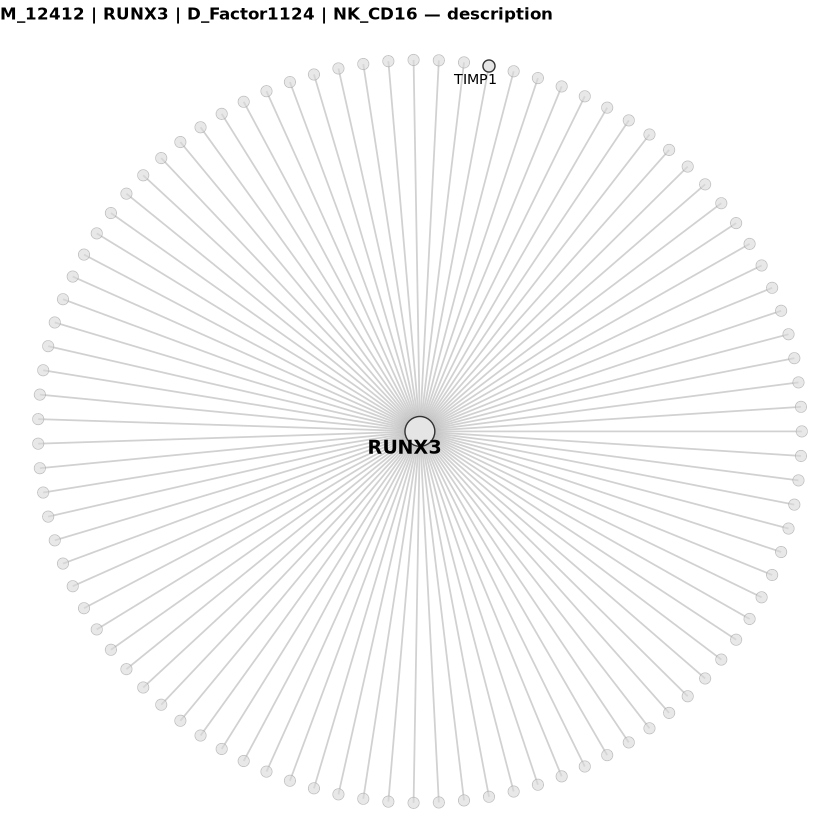

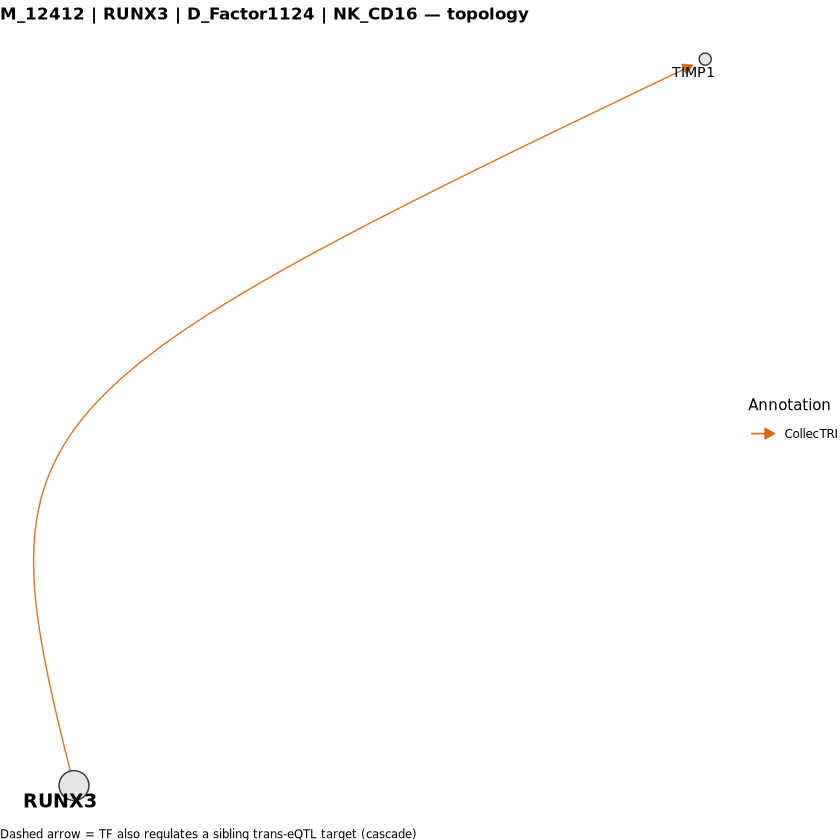

In [16]:
# --- Test 1: RUNX3 (single-graph pattern, Within-only) ---
# NOTE: factor identity now includes `program` - if this (module, gene, cell)
# combination spans more than one program, this pulls ALL of them mixed
# together. Pick the actual program value first if that matters for your check.
runx3_programs <- unique(whole_eqtl_annotated[
  Source_module == "M_12412" & Source_symbol == "RUNX3" & Source_cell == "NK_CD16"
]$program)
cat("Program(s) present for this module/gene/cell:", paste(runx3_programs, collapse = ", "), "\n")

runx3_unit <- whole_eqtl_annotated[
  Source_module == "M_12412" & Source_symbol == "RUNX3" & Source_cell == "NK_CD16" &
  program == runx3_programs[1]
]

g_runx3 <- build_factor_graph(runx3_unit)
g_runx3 <- add_cascade_edges_generic(g_runx3, runx3_unit)
layout_runx3 <- compute_fixed_layout(g_runx3)          # layout FIRST
g_runx3 <- prepare_graph_attrs(g_runx3, layout_runx3)  # then attrs, using that layout

title_text_runx3 <- paste("M_12412 | RUNX3 |", runx3_programs[1], "| NK_CD16")
p_runx3_desc <- plot_graph_description(g_runx3, layout_runx3, title_text_runx3)
p_runx3_topo <- plot_graph_topology(g_runx3, layout_runx3, title_text_runx3)

print(p_runx3_desc)
print(p_runx3_topo)

ggsave(paste0(testdir, "test_RUNX3_description.png"), p_runx3_desc, width = 8, height = 6, dpi = 150, bg = "white")
ggsave(paste0(testdir, "test_RUNX3_topology.png"), p_runx3_topo, width = 8, height = 6, dpi = 150, bg = "white")


Program(s) present for this module/gene/cell/target_cell: D_Factor804 


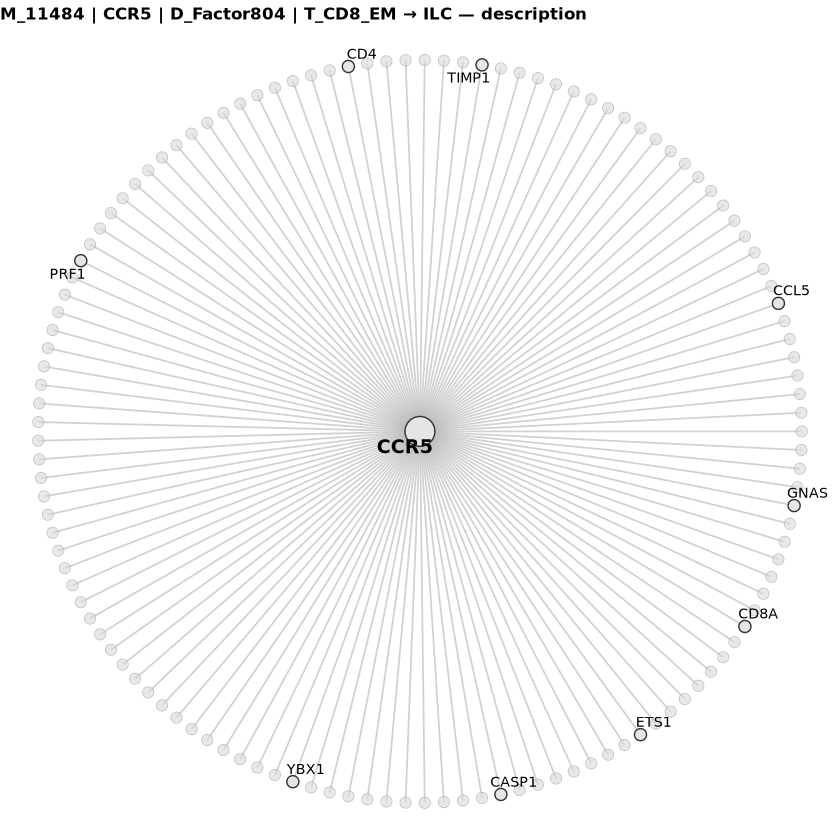

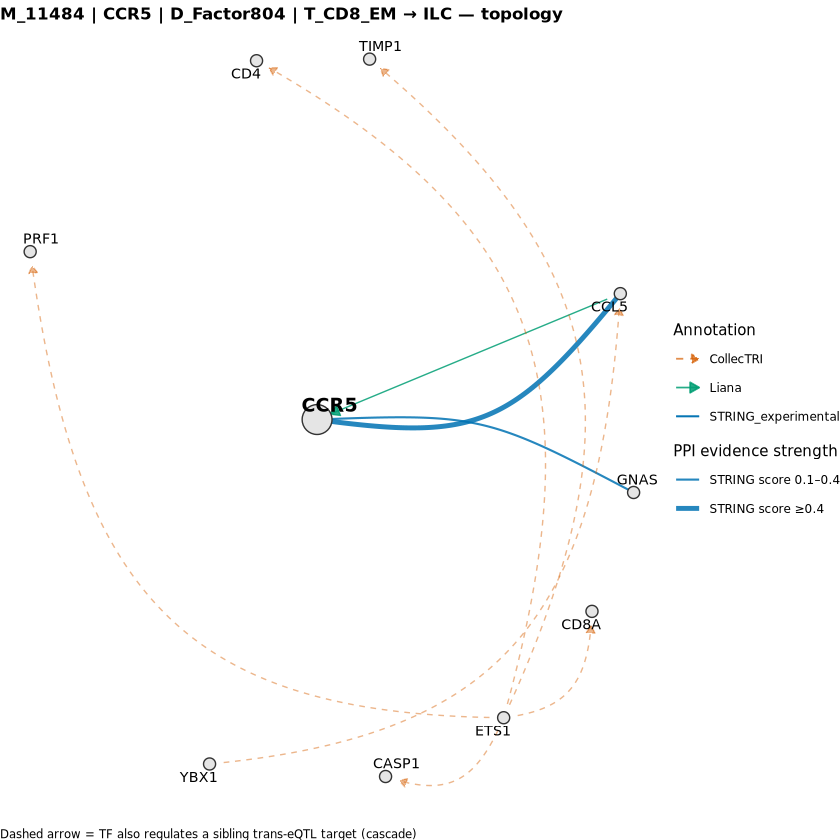

In [17]:
# --- Test 2: CCR5 (small-multiples pattern, Across-only) ---
ccr5_programs <- unique(whole_eqtl_annotated[
  Source_module == "M_11484" & Source_symbol == "CCR5" & Source_cell == "T_CD8_EM" & Target_cell == "ILC"
]$program)
cat("Program(s) present for this module/gene/cell/target_cell:", paste(ccr5_programs, collapse = ", "), "\n")

ccr5_unit <- whole_eqtl_annotated[
  Source_module == "M_11484" & Source_symbol == "CCR5" & Source_cell == "T_CD8_EM" & Target_cell == "ILC" &
  program == ccr5_programs[1]
]

g_ccr5 <- build_factor_graph(ccr5_unit)
g_ccr5 <- add_cascade_edges_generic(g_ccr5, ccr5_unit)

layout_ccr5 <- compute_fixed_layout(g_ccr5)          # layout FIRST
g_ccr5 <- prepare_graph_attrs(g_ccr5, layout_ccr5)   # THEN attrs, using that layout

title_full <- paste0("M_11484 | CCR5 | ", ccr5_programs[1], " | T_CD8_EM \u2192 ILC")
p_ccr5_desc <- plot_graph_description(g_ccr5, layout_ccr5, title_full)
p_ccr5_topo <- plot_graph_topology(g_ccr5, layout_ccr5, title_full)

print(p_ccr5_desc)
print(p_ccr5_topo)

ggsave(paste0(testdir, "test_CCR5_description.png"), p_ccr5_desc, width = 8, height = 6, dpi = 150, bg = "white")
ggsave(paste0(testdir, "test_CCR5_topology.png"), p_ccr5_topo, width = 8, height = 6, dpi = 150, bg = "white")


## Pattern 1: cis-eQTL gene = TF (Within-only)

In [18]:
qualifying_factors <- unique(
  whole_eqtl_annotated[
    edge_type_composition == "Within-only" &
    !is.na(edge_role) &
    grepl("Source_TF->Target", edge_role, fixed = TRUE),
    .(Source_module, Source_gene, program)
  ]
)
tf_pattern_units <- whole_eqtl_annotated[
  qualifying_factors, on = .(Source_module, Source_gene, program), nomatch = 0
][, .(Source_module, Source_gene, program, Source_symbol, Source_cell)] |> unique()

manifest_tf <- render_pattern_batch(tf_pattern_units, paste0(outdir, "cis_eQTL_TF/"))
print(manifest_tf)


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'M_1005 | MYC | D_Factor679 | T_CD8_EMRA — description' in 'mbcsToSbcs': - substituted for — (U+2014)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'STRING score 0.1–0.4' in 'mbcsToSbcs': - substituted for – (U+2013)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'M_1005 | MYC | D_Factor679 | T_CD8_EMRA — topology' in 'mbcsToSbcs': - substituted for — (U+2014)”


[1/135] Saved M_1005_MYC_D_Factor679_T_CD8_EMRA (description + topology; n_edges=14, n_annotated=3, n_cascade_edges=0)


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'M_12317 | BCL6 | D_Factor372 | Monocyte_CD14 — description' in 'mbcsToSbcs': - substituted for — (U+2014)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'STRING score 0.1–0.4' in 'mbcsToSbcs': - substituted for – (U+2013)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'M_12317 | BCL6 | D_Factor372 | Monocyte_CD14 — topology' in 'mbcsToSbcs': - substituted for — (U+2014)”


[2/135] Saved M_12317_BCL6_D_Factor372_Monocyte_CD14_cascade (description + topology; n_edges=94, n_annotated=3, n_cascade_edges=3)


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'M_12317 | BCL6 | D_Factor372 | Monocyte_CD16 — description' in 'mbcsToSbcs': - substituted for — (U+2014)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'STRING score 0.1–0.4' in 'mbcsToSbcs': - substituted for – (U+2013)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'M_12317 | BCL6 | D_Factor372 | Monocyte_CD16 — topology' in 'mbcsToSbcs': - substituted for — (U+2014)”


...

[133/135] Saved M_7293_MBD2_D_Factor208_Monocyte_CD14_cascade (description + topology; n_edges=58, n_annotated=1, n_cascade_edges=7)


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'M_7293 | MBD2 | D_Factor208 | Monocyte_CD16 — description' in 'mbcsToSbcs': - substituted for — (U+2014)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'M_7293 | MBD2 | D_Factor208 | Monocyte_CD16 — topology' in 'mbcsToSbcs': - substituted for — (U+2014)”


[134/135] Saved M_7293_MBD2_D_Factor208_Monocyte_CD16_cascade (description + topology; n_edges=58, n_annotated=1, n_cascade_edges=7)


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'M_8197 | CEBPB | D_Factor1180 | Monocyte_CD16 — description' in 'mbcsToSbcs': - substituted for — (U+2014)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'STRING score 0.1–0.4' in 'mbcsToSbcs': - substituted for – (U+2013)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'M_8197 | CEBPB | D_Factor1180 | Monocyte_CD16 — topology' in 'mbcsToSbcs': - substituted for — (U+2014)”


[135/135] Saved M_8197_CEBPB_D_Factor1180_Monocyte_CD16_cascade (description + topology; n_edges=86, n_annotated=5, n_cascade_edges=4)
     Source_module Source_symbol      program   Source_cell
            <char>        <char>       <char>        <char>
  1:        M_1005           MYC  D_Factor679    T_CD8_EMRA
  2:       M_12317          BCL6  D_Factor372 Monocyte_CD14
  3:       M_12317          BCL6  D_Factor372 Monocyte_CD16
  4:       M_12412         RUNX3 D_Factor1124       NK_CD16
  5:       M_12412         RUNX3  D_Factor374       NK_CD16
 ---                                                       
131:        M_7217         NFKB1  D_Factor340   T_CD4_naive
132:        M_7217         NFKB1  D_Factor881   T_CD4_naive
133:        M_7293          MBD2  D_Factor208 Monocyte_CD14
134:        M_7293          MBD2  D_Factor208 Monocyte_CD16
135:        M_8197         CEBPB D_Factor1180 Monocyte_CD16
                                           file_base n_edges n_annotated
            

## Pattern 2: RBP cis-eQTL (widespread targets, Within-only)

In [19]:
rbp_widespread_candidates <- whole_eqtl_annotated[
  edge_type_composition == "Within-only" &
  !is.na(edge_role) &
  grepl("Source_RBP->Target", edge_role, fixed = TRUE),
  .(n_distinct_rbp_targets = uniqueN(Target_gene)),
  by = .(Source_module, Source_gene, program, Source_symbol, Source_cell)
]
rbp_pattern_units <- rbp_widespread_candidates[, .(Source_module, Source_gene, program, Source_symbol, Source_cell)]

manifest_rbp <- render_pattern_batch(rbp_pattern_units, paste0(outdir, "cis_eQTL_RBP/"))
print(manifest_rbp)


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'M_17769 | CPSF6 | D_Factor202 | Monocyte_CD14 — description' in 'mbcsToSbcs': - substituted for — (U+2014)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'M_17769 | CPSF6 | D_Factor202 | Monocyte_CD14 — topology' in 'mbcsToSbcs': - substituted for — (U+2014)”


[1/3] Saved M_17769_CPSF6_D_Factor202_Monocyte_CD14 (description + topology; n_edges=30, n_annotated=14, n_cascade_edges=0)


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'M_17769 | CPSF6 | D_Factor705 | Monocyte_CD14 — description' in 'mbcsToSbcs': - substituted for — (U+2014)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'STRING score 0.1–0.4' in 'mbcsToSbcs': - substituted for – (U+2013)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'M_17769 | CPSF6 | D_Factor705 | Monocyte_CD14 — topology' in 'mbcsToSbcs': - substituted for — (U+2014)”


[2/3] Saved M_17769_CPSF6_D_Factor705_Monocyte_CD14_cascade (description + topology; n_edges=53, n_annotated=26, n_cascade_edges=3)


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'M_41120 | QKI | D_Factor1085 | T_CD4_naive — description' in 'mbcsToSbcs': - substituted for — (U+2014)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'M_41120 | QKI | D_Factor1085 | T_CD4_naive — topology' in 'mbcsToSbcs': - substituted for — (U+2014)”


[3/3] Saved M_41120_QKI_D_Factor1085_T_CD4_naive (description + topology; n_edges=21, n_annotated=4, n_cascade_edges=0)
   Source_module Source_symbol      program   Source_cell
          <char>        <char>       <char>        <char>
1:       M_17769         CPSF6  D_Factor202 Monocyte_CD14
2:       M_17769         CPSF6  D_Factor705 Monocyte_CD14
3:       M_41120           QKI D_Factor1085   T_CD4_naive
                                         file_base n_edges n_annotated
                                            <char>   <int>       <int>
1:         M_17769_CPSF6_D_Factor202_Monocyte_CD14      30          14
2: M_17769_CPSF6_D_Factor705_Monocyte_CD14_cascade      53          26
3:            M_41120_QKI_D_Factor1085_T_CD4_naive      21           4
   n_cascade_edges has_cascade
             <int>      <lgcl>
1:               0       FALSE
2:               3        TRUE
3:               0       FALSE


## Pattern 3: Across-only factors with >=1 Liana annotation

In [20]:
qualifying_factors_lr <- unique(
  whole_eqtl_annotated[
    edge_type_composition == "Across-only" &
    !is.na(edge_resource) &
    grepl("Liana", edge_resource, fixed = TRUE),
    .(Source_module, Source_gene, program)
  ]
)

cat("Qualifying Across-only factors with >=1 Liana L-R annotation:", nrow(qualifying_factors_lr), "\n")
print(qualifying_factors_lr)

LR_across_pattern <- whole_eqtl_annotated[
  qualifying_factors_lr, on = .(Source_module, Source_gene, program), nomatch = 0
]

stopifnot(all(LR_across_pattern$edge_type_composition == "Across-only"))
stopifnot(all(LR_across_pattern$Source_cell != LR_across_pattern$Target_cell))

cat("\nTotal edges pulled:", nrow(LR_across_pattern), "\n")
cat("Annotated edges:", sum(!is.na(LR_across_pattern$edge_role)), "\n")

lr_graph_units <- LR_across_pattern[, .(
  n_target_cells = uniqueN(Target_cell),
  target_cells   = paste(sort(unique(Target_cell)), collapse = ", "),
  n_edges        = .N,
  n_annotated    = sum(!is.na(edge_role))
), by = .(Source_module, Source_gene, program, Source_symbol, Source_cell)]

print(lr_graph_units[order(-n_annotated)])


Qualifying Across-only factors with >=1 Liana L-R annotation: 6 
Key: <Source_module, Source_gene, program>
   Source_module     Source_gene      program
          <char>          <char>       <char>
1:       M_11484 ENSG00000160791  D_Factor804
2:       M_14775 ENSG00000110651  D_Factor519
3:       M_18253 ENSG00000164307  D_Factor667
4:       M_27450 ENSG00000042980  D_Factor292
5:        M_3005 ENSG00000110848 D_Factor1139
6:        M_6279 ENSG00000163823 D_Factor1147

Total edges pulled: 12738 
Annotated edges: 158 
    Source_module     Source_gene      program Source_symbol       Source_cell
           <char>          <char>       <char>        <char>            <char>
 1:       M_18253 ENSG00000164307  D_Factor667         ERAP1           B_naive
 2:       M_18253 ENSG00000164307  D_Factor667         ERAP1     Monocyte_CD14
 3:       M_18253 ENSG00000164307  D_Factor667         ERAP1     Monocyte_CD16
 4:       M_18253 ENSG00000164307  D_Factor667         ERAP1           NK_CD16


In [21]:
pattern_dir_lr <- paste0(outdir, "cis_eQTL_LR_across/")
lr_units <- unique(lr_graph_units[, .(Source_module, Source_gene, program, Source_symbol, Source_cell)])

manifest_lr <- render_pattern_batch_small_multiples(lr_units, LR_across_pattern, pattern_dir_lr)
print(manifest_lr)


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'CCR5 (D_Factor804, T_CD8_EM) → ILC — description' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'CCR5 (D_Factor804, T_CD8_EM) → ILC — description' in 'mbcsToSbcs': - substituted for — (U+2014)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'CCR5 (D_Factor804, T_CD8_EM) → T_CD4_EM — description' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'CCR5 (D_Factor804, T_CD8_EM) → T_CD4_EM — description' in 'mbcsToSbcs': - substituted for — (U+2014)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'CCR5 (D_Factor804, T_CD8_EM) → T_MAIT — description' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text

[1/22] Saved M_11484_CCR5_D_Factor804_T_CD8_EM_to_ILC_T_CD4_EM_T_MAIT_T_gd_cascade (description + topology; n_target_cells=4, n_edges=500, n_annotated=8, n_cascade_edges=24)


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'CD81 (D_Factor519, T_CD4_CM) → NK_CD16 — description' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'CD81 (D_Factor519, T_CD4_CM) → NK_CD16 — description' in 'mbcsToSbcs': - substituted for — (U+2014)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'CD81 (D_Factor519, T_CD4_CM) → NK_CD56bright — description' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'CD81 (D_Factor519, T_CD4_CM) → NK_CD56bright — description' in 'mbcsToSbcs': - substituted for — (U+2014)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'CD81 (D_Factor519, T_CD4_CM) → NK_prolif — description' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid

[2/22] Saved M_14775_CD81_D_Factor519_T_CD4_CM_to_NK_CD16_NK_CD56bright_NK_prolif (description + topology; n_target_cells=3, n_edges=135, n_annotated=6, n_cascade_edges=0)


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'CD81 (D_Factor519, T_CD4_EM) → NK_CD16 — description' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'CD81 (D_Factor519, T_CD4_EM) → NK_CD16 — description' in 'mbcsToSbcs': - substituted for — (U+2014)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'CD81 (D_Factor519, T_CD4_EM) → NK_CD56bright — description' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'CD81 (D_Factor519, T_CD4_EM) → NK_CD56bright — description' in 'mbcsToSbcs': - substituted for — (U+2014)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'CD81 (D_Factor519, T_CD4_EM) → NK_prolif — description' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid

...

[20/22] Saved M_3005_CD69_D_Factor1139_cDC2_to_T_CD4_EM_T_CD8_EM_T_CD8_prolif_T_MAIT_and_1_more (description + topology; n_target_cells=5, n_edges=70, n_annotated=5, n_cascade_edges=0)


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'CCR1 (D_Factor1147, Monocyte_CD16) → ILC — description' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'CCR1 (D_Factor1147, Monocyte_CD16) → ILC — description' in 'mbcsToSbcs': - substituted for — (U+2014)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'CCR1 (D_Factor1147, Monocyte_CD16) → T_CD4_EM — description' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'CCR1 (D_Factor1147, Monocyte_CD16) → T_CD4_EM — description' in 'mbcsToSbcs': - substituted for — (U+2014)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'CCR1 (D_Factor1147, Monocyte_CD16) → T_MAIT — description' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning messag

[21/22] Saved M_6279_CCR1_D_Factor1147_Monocyte_CD16_to_ILC_T_CD4_EM_T_MAIT_T_gd_cascade (description + topology; n_target_cells=4, n_edges=388, n_annotated=4, n_cascade_edges=16)


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'CCR1 (D_Factor1147, cDC2) → ILC — description' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'CCR1 (D_Factor1147, cDC2) → ILC — description' in 'mbcsToSbcs': - substituted for — (U+2014)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'CCR1 (D_Factor1147, cDC2) → T_CD4_EM — description' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'CCR1 (D_Factor1147, cDC2) → T_CD4_EM — description' in 'mbcsToSbcs': - substituted for — (U+2014)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'CCR1 (D_Factor1147, cDC2) → T_MAIT — description' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAn

[22/22] Saved M_6279_CCR1_D_Factor1147_cDC2_to_ILC_T_CD4_EM_T_MAIT_T_gd_cascade (description + topology; n_target_cells=4, n_edges=388, n_annotated=4, n_cascade_edges=16)
    Source_module Source_symbol      program       Source_cell
           <char>        <char>       <char>            <char>
 1:       M_11484          CCR5  D_Factor804          T_CD8_EM
 2:       M_14775          CD81  D_Factor519          T_CD4_CM
 3:       M_14775          CD81  D_Factor519          T_CD4_EM
 4:       M_14775          CD81  D_Factor519       T_CD4_naive
 5:       M_14775          CD81  D_Factor519          T_CD8_EM
 6:       M_14775          CD81  D_Factor519        T_CD8_EMRA
 7:       M_18253         ERAP1  D_Factor667           B_naive
 8:       M_18253         ERAP1  D_Factor667     Monocyte_CD14
 9:       M_18253         ERAP1  D_Factor667     Monocyte_CD16
10:       M_18253         ERAP1  D_Factor667           NK_CD16
11:       M_18253         ERAP1  D_Factor667        T_CD4_Treg
12:       

## Mixed factors with >=1 Liana OR MEROPS annotation

In [22]:
qualifying_factors_mixed <- unique(
  whole_eqtl_annotated[
    edge_type_composition == "Mixed" &
    !is.na(edge_resource) &
    (grepl("Liana", edge_resource, fixed = TRUE) | grepl("MEROPS", edge_resource, fixed = TRUE)),
    .(Source_module, Source_gene, program)
  ]
)
cat("Qualifying Mixed factors with >=1 Liana or MEROPS annotation:", nrow(qualifying_factors_mixed), "\n")

mixed_factors_all <- unique(whole_eqtl_annotated[edge_type_composition == "Mixed", .(Source_module, Source_gene, program)])
cat("Total Mixed factors:", nrow(mixed_factors_all), "\n")

mixed_any_annotation <- whole_eqtl_annotated[edge_type_composition == "Mixed" & !is.na(edge_role)]
cat("Mixed edges with ANY annotation (any resource):", nrow(mixed_any_annotation), "\n")

if (nrow(mixed_any_annotation) > 0) {
  all_resources_in_mixed <- unlist(strsplit(mixed_any_annotation$edge_resource, ";"))
  resource_names_in_mixed <- sapply(all_resources_in_mixed, extract_resource_name)
  print(table(resource_names_in_mixed))
}

cat("\nNote: with the program-stratified factor definition, Mixed composition may no",
    "longer occur at all (program-splitting can fully resolve what used to look Mixed",
    "at the coarser module x gene level) - if mixed_factors_all is 0, that is expected,",
    "not an error.\n", sep = " ")

if (nrow(mixed_factors_all) > 0) {
  cat("\nConfirmed status: ",
      sum(mixed_factors_all$Source_module %in% qualifying_factors_mixed$Source_module), "\n")
}


Qualifying Mixed factors with >=1 Liana or MEROPS annotation: 0 
Total Mixed factors: 0 
Mixed edges with ANY annotation (any resource): 0 

Note: with the program-stratified factor definition, Mixed composition may no longer occur at all (program-splitting can fully resolve what used to look Mixed at the coarser module x gene level) - if mixed_factors_all is 0, that is expected, not an error.


## Across-only factors with >=1 MEROPS annotation

In [23]:
qualifying_factors_merops <- unique(
  whole_eqtl_annotated[
    edge_type_composition == "Across-only" &
    !is.na(edge_resource) &
    grepl("MEROPS", edge_resource, fixed = TRUE),
    .(Source_module, Source_gene, program)
  ]
)

cat("Qualifying Across-only factors with >=1 MEROPS annotation:", nrow(qualifying_factors_merops), "\n")
print(qualifying_factors_merops)

MEROPS_across_pattern <- whole_eqtl_annotated[
  qualifying_factors_merops, on = .(Source_module, Source_gene, program), nomatch = 0
]

stopifnot(all(MEROPS_across_pattern$edge_type_composition == "Across-only"))
stopifnot(all(MEROPS_across_pattern$Source_cell != MEROPS_across_pattern$Target_cell))

cat("\nTotal edges pulled:", nrow(MEROPS_across_pattern), "\n")
cat("Annotated edges:", sum(!is.na(MEROPS_across_pattern$edge_role)), "\n")

merops_graph_units <- MEROPS_across_pattern[, .(
  n_target_cells = uniqueN(Target_cell),
  target_cells   = paste(sort(unique(Target_cell)), collapse = ", "),
  n_edges        = .N,
  n_annotated    = sum(!is.na(edge_role))
), by = .(Source_module, Source_gene, program, Source_symbol, Source_cell)]

print(merops_graph_units[order(-n_annotated)])


Qualifying Across-only factors with >=1 MEROPS annotation: 2 
Key: <Source_module, Source_gene, program>
   Source_module     Source_gene     program
          <char>          <char>      <char>
1:       M_23324 ENSG00000110660 D_Factor413
2:       M_34902 ENSG00000221914 D_Factor418

Total edges pulled: 96 
Annotated edges: 6 
   Source_module     Source_gene     program Source_symbol   Source_cell
          <char>          <char>      <char>        <char>        <char>
1:       M_23324 ENSG00000110660 D_Factor413       SLC35F2      T_CD4_CM
2:       M_34902 ENSG00000221914 D_Factor418       PPP2R2A Monocyte_CD14
   n_target_cells                target_cells n_edges n_annotated
            <int>                      <char>   <int>       <int>
1:              3 T_CD4_CTL, T_CD8_EMRA, T_gd      63           3
2:              3 T_CD4_CTL, T_CD8_EMRA, T_gd      33           3


In [24]:
pattern_dir_merops <- paste0(outdir, "cis_eQTL_MEROPS_across/")
merops_units <- unique(merops_graph_units[, .(Source_module, Source_gene, program, Source_symbol, Source_cell)])

manifest_merops <- render_pattern_batch_small_multiples(merops_units, MEROPS_across_pattern, pattern_dir_merops)
print(manifest_merops)


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'SLC35F2 (D_Factor413, T_CD4_CM) → T_CD4_CTL — description' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'SLC35F2 (D_Factor413, T_CD4_CM) → T_CD4_CTL — description' in 'mbcsToSbcs': - substituted for — (U+2014)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'SLC35F2 (D_Factor413, T_CD4_CM) → T_CD8_EMRA — description' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'SLC35F2 (D_Factor413, T_CD4_CM) → T_CD8_EMRA — description' in 'mbcsToSbcs': - substituted for — (U+2014)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'SLC35F2 (D_Factor413, T_CD4_CM) → T_gd — description' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message

[1/2] Saved M_23324_SLC35F2_D_Factor413_T_CD4_CM_to_T_CD4_CTL_T_CD8_EMRA_T_gd (description + topology; n_target_cells=3, n_edges=63, n_annotated=3, n_cascade_edges=0)


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'PPP2R2A (D_Factor418, Monocyte_CD14) → T_CD4_CTL — description' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'PPP2R2A (D_Factor418, Monocyte_CD14) → T_CD4_CTL — description' in 'mbcsToSbcs': - substituted for — (U+2014)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'PPP2R2A (D_Factor418, Monocyte_CD14) → T_CD8_EMRA — description' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'PPP2R2A (D_Factor418, Monocyte_CD14) → T_CD8_EMRA — description' in 'mbcsToSbcs': - substituted for — (U+2014)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'PPP2R2A (D_Factor418, Monocyte_CD14) → T_gd — description' in 'mbcsToSbcs': -> substituted for → 

[2/2] Saved M_34902_PPP2R2A_D_Factor418_Monocyte_CD14_to_T_CD4_CTL_T_CD8_EMRA_T_gd (description + topology; n_target_cells=3, n_edges=33, n_annotated=3, n_cascade_edges=0)
   Source_module Source_symbol     program   Source_cell
          <char>        <char>      <char>        <char>
1:       M_23324       SLC35F2 D_Factor413      T_CD4_CM
2:       M_34902       PPP2R2A D_Factor418 Monocyte_CD14
              target_cells_all n_target_cells
                        <char>          <int>
1: T_CD4_CTL, T_CD8_EMRA, T_gd              3
2: T_CD4_CTL, T_CD8_EMRA, T_gd              3
                                                                file_base
                                                                   <char>
1:      M_23324_SLC35F2_D_Factor413_T_CD4_CM_to_T_CD4_CTL_T_CD8_EMRA_T_gd
2: M_34902_PPP2R2A_D_Factor418_Monocyte_CD14_to_T_CD4_CTL_T_CD8_EMRA_T_gd
   n_edges n_annotated n_cascade_edges has_cascade
     <int>       <int>           <num>      <lgcl>
1:      63        

# Checks before moving to other patterns

In [25]:
factors_TF <- unique(qualifying_factors[, .(Source_module, Source_gene, program)])
factors_TF[, category := "TF_cis_eQTL"]

factors_RBP <- unique(rbp_pattern_units[, .(Source_module, Source_gene, program)])
factors_RBP[, category := "RBP_cis_eQTL"]

factors_LR <- unique(qualifying_factors_lr[, .(Source_module, Source_gene, program)])
factors_LR[, category := "LR_across"]

factors_MEROPS <- unique(qualifying_factors_merops[, .(Source_module, Source_gene, program)])
factors_MEROPS[, category := "MEROPS_across"]

cat("Factors per category:\n")
cat("  TF_cis_eQTL: ", nrow(factors_TF), "\n")
cat("  RBP_cis_eQTL:", nrow(factors_RBP), "\n")
cat("  LR_across:   ", nrow(factors_LR), "\n")
cat("  MEROPS_across:", nrow(factors_MEROPS), "\n")

all_category_sets <- list(
  TF_cis_eQTL    = unique(factors_TF[, .(Source_module, Source_gene, program)]),
  RBP_cis_eQTL   = unique(factors_RBP[, .(Source_module, Source_gene, program)]),
  LR_across      = unique(factors_LR[, .(Source_module, Source_gene, program)]),
  MEROPS_across  = unique(factors_MEROPS[, .(Source_module, Source_gene, program)])
)

cat("\nPairwise overlap matrix (n shared factors):\n")
overlap_matrix <- sapply(all_category_sets, function(a) {
  sapply(all_category_sets, function(b) nrow(fintersect(a, b)))
})
print(overlap_matrix)

all_categorized <- rbindlist(list(factors_TF, factors_RBP, factors_LR, factors_MEROPS))
factor_category_counts <- all_categorized[, .(n_categories = uniqueN(category),
                                                categories = paste(sort(unique(category)), collapse = ", ")),
                                            by = .(Source_module, Source_gene, program)]

cat("\nFactors appearing in >1 category (should be empty if mutually exclusive):\n")
print(factor_category_counts[n_categories > 1])

n_unique_categorized <- uniqueN(all_categorized[, .(Source_module, Source_gene, program)])
cat("\nTotal unique factors across all categories:", n_unique_categorized, "\n")
cat("(Sum of individual category counts:", nrow(factors_TF) + nrow(factors_RBP) + nrow(factors_LR) + nrow(factors_MEROPS), ")\n")

all_factors_total <- unique(whole_eqtl_annotated[, .(Source_module, Source_gene, program)])
cat("\nTotal factors overall:", nrow(all_factors_total), "\n")

remaining_factors <- fsetdiff(all_factors_total, unique(all_categorized[, .(Source_module, Source_gene, program)]))
cat("Remaining, uncategorized factors:", nrow(remaining_factors), "\n")

stopifnot(nrow(remaining_factors) + n_unique_categorized == nrow(all_factors_total))
cat("Sanity check passed: categorized + remaining = total.\n")


Factors per category:
  TF_cis_eQTL:  86 
  RBP_cis_eQTL: 3 
  LR_across:    6 
  MEROPS_across: 2 

Pairwise overlap matrix (n shared factors):
              TF_cis_eQTL RBP_cis_eQTL LR_across MEROPS_across
TF_cis_eQTL            86            0         0             0
RBP_cis_eQTL            0            3         0             0
LR_across               0            0         6             0
MEROPS_across           0            0         0             2

Factors appearing in >1 category (should be empty if mutually exclusive):
Empty data.table (0 rows and 5 cols): Source_module,Source_gene,program,n_categories,categories

Total unique factors across all categories: 97 
(Sum of individual category counts: 97 )

Total factors overall: 3167 
Remaining, uncategorized factors: 3070 
Sanity check passed: categorized + remaining = total.


# Patterns 2

## PPI_reciprocal_TF

cis-eQTL PPI-linked (either STRING band) to a trans-eQTL that is itself
independently annotated as directly regulating the cis-eQTL gene
(`Target_TF->Source`). Searched within `remaining_factors` only.

In [26]:
ppi_lenient_edges <- whole_eqtl_annotated[
  remaining_factors, on = .(Source_module, Source_gene, program), nomatch = 0
][!is.na(edge_role) & grepl("PPI \\(STRING_experimental >=0.1 <0.4\\)", edge_role)]

cat("PPI lenient-band (0.1-0.4) edges within remaining factors:", nrow(ppi_lenient_edges), "\n")

pattern_B_lenient <- ppi_lenient_edges[grepl("Target_TF->Source", edge_role, fixed = TRUE)]
cat("\nPattern B (lenient PPI) qualifying edges:", nrow(pattern_B_lenient), "\n")
print(unique(pattern_B_lenient[, .(Source_module, Source_gene, program, Source_symbol, Source_cell,
                                     Target_gene, Target_symbol, Target_cell, edge_type_composition)]))

pattern_B_either_band <- whole_eqtl_annotated[
  remaining_factors, on = .(Source_module, Source_gene, program), nomatch = 0
][!is.na(edge_role) &
  (grepl("PPI \\(STRING_experimental", edge_role)) &
  grepl("Target_TF->Source", edge_role, fixed = TRUE)]

cat("\nPattern B (either PPI band) qualifying edges:", nrow(pattern_B_either_band), "\n")
print(unique(pattern_B_either_band[, .(Source_module, Source_gene, program, Source_symbol, Source_cell,
                                         Target_gene, Target_symbol, Target_cell, edge_type_composition)]))


PPI lenient-band (0.1-0.4) edges within remaining factors: 1763 

Pattern B (lenient PPI) qualifying edges: 9 
Key: <Source_module, Source_gene, program>
   Source_module     Source_gene     program Source_symbol Source_cell
          <char>          <char>      <char>        <char>      <char>
1:       M_12412 ENSG00000020633 D_Factor756         RUNX3     NK_CD16
2:        M_9521 ENSG00000084207 D_Factor471         GSTP1  T_CD4_Treg
3:        M_9521 ENSG00000084207 D_Factor471         GSTP1  T_CD4_Treg
4:        M_9521 ENSG00000084207 D_Factor471         GSTP1  T_CD4_Treg
5:        M_9521 ENSG00000084207 D_Factor471         GSTP1  T_CD4_Treg
6:        M_9521 ENSG00000084207 D_Factor471         GSTP1  T_CD4_Treg
7:        M_9521 ENSG00000084207 D_Factor471         GSTP1  T_CD4_Treg
8:        M_9521 ENSG00000084207 D_Factor471         GSTP1  T_CD4_Treg
9:        M_9521 ENSG00000084207 D_Factor471         GSTP1  T_CD4_Treg
       Target_gene Target_symbol Target_cell edge_type_compositio

In [27]:
ppi_reciprocal_units <- unique(pattern_B_either_band[, .(Source_module, Source_gene, program, Source_symbol, Source_cell)])
print(ppi_reciprocal_units)


Key: <Source_module, Source_gene, program>
   Source_module     Source_gene     program Source_symbol Source_cell
          <char>          <char>      <char>        <char>      <char>
1:       M_12412 ENSG00000020633 D_Factor756         RUNX3     NK_CD16
2:        M_9521 ENSG00000084207 D_Factor471         GSTP1  T_CD4_Treg


In [28]:
pattern_dir_ppi_tf <- paste0(outdir, "PPI_reciprocal_TF/")

ppi_reciprocal_full <- whole_eqtl_annotated[
  ppi_reciprocal_units[, .(Source_module, Source_gene, program, Source_cell)],
  on = .(Source_module, Source_gene, program, Source_cell), nomatch = 0
]

manifest_ppi_reciprocal <- render_pattern_batch_small_multiples(ppi_reciprocal_units, ppi_reciprocal_full, pattern_dir_ppi_tf)
print(manifest_ppi_reciprocal)


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'RUNX3 (D_Factor756, NK_CD16) → NK_CD16 — description' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'RUNX3 (D_Factor756, NK_CD16) → NK_CD16 — description' in 'mbcsToSbcs': - substituted for — (U+2014)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'M_12412 | RUNX3 | D_Factor756 | NK_CD16 — description' in 'mbcsToSbcs': - substituted for — (U+2014)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'RUNX3 (D_Factor756, NK_CD16) → NK_CD16 — topology' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'RUNX3 (D_Factor756, NK_CD16) → NK_CD16 — topology' in 'mbcsToSbcs': - substituted for — (U+2014)”
Warning message in grid.Call.graphics(C_tex

[1/2] Saved M_12412_RUNX3_D_Factor756_NK_CD16_to_NK_CD16_cascade (description + topology; n_target_cells=1, n_edges=36, n_annotated=1, n_cascade_edges=2)


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'GSTP1 (D_Factor471, T_CD4_Treg) → T_CD4_CM — description' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'GSTP1 (D_Factor471, T_CD4_Treg) → T_CD4_CM — description' in 'mbcsToSbcs': - substituted for — (U+2014)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'GSTP1 (D_Factor471, T_CD4_Treg) → T_CD4_naive — description' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'GSTP1 (D_Factor471, T_CD4_Treg) → T_CD4_naive — description' in 'mbcsToSbcs': - substituted for — (U+2014)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'GSTP1 (D_Factor471, T_CD4_Treg) → T_CD8_CM — description' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning mes

[2/2] Saved M_9521_GSTP1_D_Factor471_T_CD4_Treg_to_T_CD4_CM_T_CD4_naive_T_CD8_CM_T_CD8_naive_cascade (description + topology; n_target_cells=4, n_edges=136, n_annotated=12, n_cascade_edges=16)
   Source_module Source_symbol     program Source_cell
          <char>        <char>      <char>      <char>
1:       M_12412         RUNX3 D_Factor756     NK_CD16
2:        M_9521         GSTP1 D_Factor471  T_CD4_Treg
                               target_cells_all n_target_cells
                                         <char>          <int>
1:                                      NK_CD16              1
2: T_CD4_CM, T_CD4_naive, T_CD8_CM, T_CD8_naive              4
                                                                                  file_base
                                                                                     <char>
1:                                     M_12412_RUNX3_D_Factor756_NK_CD16_to_NK_CD16_cascade
2: M_9521_GSTP1_D_Factor471_T_CD4_Treg_to_T_CD4_CM_T_CD4_na

## cis-eQTL PPI to TF that cascades

cis-eQTL PPI-linked (either band) to a trans-eQTL that is generically a TF,
restricted to Within-only, within `remaining_factors`.

In [29]:
ppi_either_within_remaining <- whole_eqtl_annotated[
  remaining_factors, on = .(Source_module, Source_gene, program), nomatch = 0
][edge_type_composition == "Within-only" &
  !is.na(edge_role) &
  grepl("PPI \\(STRING_experimental", edge_role)]

cat("Within-only PPI (either band) edges in remaining factors:", nrow(ppi_either_within_remaining), "\n")

pattern_A_within_relaxed <- ppi_either_within_remaining[Target_gene %in% tf_genes_generic]
cat("Qualifying edges (trans-eQTL is a TF, generically, either PPI band):", nrow(pattern_A_within_relaxed), "\n")
print(unique(pattern_A_within_relaxed[, .(Source_module, Source_gene, program, Source_symbol, Source_cell,
                                            Target_gene, Target_symbol, Target_cell, edge_role)]))

qualifying_factors_A_relaxed <- unique(pattern_A_within_relaxed[, .(Source_module, Source_gene, program, Source_cell)])
cat("\nDistinct qualifying (factor, cell) units:", nrow(qualifying_factors_A_relaxed), "\n")


Within-only PPI (either band) edges in remaining factors: 704 
Qualifying edges (trans-eQTL is a TF, generically, either PPI band): 70 
Key: <Source_module, Source_gene, program>
    Source_module     Source_gene      program Source_symbol   Source_cell
           <char>          <char>       <char>        <char>        <char>
 1:       M_12412 ENSG00000020633  D_Factor756         RUNX3       NK_CD16
 2:       M_12735 ENSG00000134954  D_Factor269          ETS1       NK_CD16
 3:       M_13007 ENSG00000023191  D_Factor612          RNH1 Monocyte_CD14
 4:       M_13007 ENSG00000023191  D_Factor612          RNH1 Monocyte_CD16
 5:       M_13007 ENSG00000023191  D_Factor612          RNH1          cDC2
 6:       M_13715 ENSG00000092067  D_Factor701         CEBPE Monocyte_CD14
 7:       M_13715 ENSG00000092067   D_Factor97         CEBPE Monocyte_CD14
 8:       M_15130 ENSG00000084207  D_Factor185         GSTP1      T_CD4_CM
 9:       M_15130 ENSG00000084207  D_Factor185         GSTP1      T_CD8

#### Restrict to cascade-positive units (using the generic detector)

In [30]:
cascade_check_list <- list()
for (i in seq_len(nrow(qualifying_factors_A_relaxed))) {
  fu <- qualifying_factors_A_relaxed[i]
  unit_data <- whole_eqtl_annotated[
    Source_module == fu$Source_module & Source_gene == fu$Source_gene &
    program       == fu$program       & Source_cell == fu$Source_cell
  ]
  g <- build_factor_graph(unit_data)
  g <- add_cascade_edges_generic(g, unit_data)
  n_cascade_this <- graph_attr(g, "n_cascade_edges")

  cascade_check_list[[i]] <- data.table(
    Source_module = fu$Source_module, Source_gene = fu$Source_gene, program = fu$program,
    Source_cell = fu$Source_cell, n_cascade_edges = n_cascade_this
  )
}
cascade_check_dt <- rbindlist(cascade_check_list)
print(cascade_check_dt)
cat("\nUnits with >=1 cascade edge:", sum(cascade_check_dt$n_cascade_edges > 0), "/", nrow(cascade_check_dt), "\n")

cascade_positive_units <- merge(
  cascade_check_dt[n_cascade_edges > 0, .(Source_module, Source_gene, program, Source_cell)],
  unique(whole_eqtl_annotated[, .(Source_module, Source_gene, program, Source_symbol)]),
  by = c("Source_module", "Source_gene", "program")
)
print(cascade_positive_units)


    Source_module     Source_gene      program   Source_cell n_cascade_edges
           <char>          <char>       <char>        <char>           <int>
 1:       M_12412 ENSG00000020633  D_Factor756       NK_CD16               2
 2:       M_12735 ENSG00000134954  D_Factor269       NK_CD16               0
 3:       M_13007 ENSG00000023191  D_Factor612 Monocyte_CD14               7
 4:       M_13007 ENSG00000023191  D_Factor612 Monocyte_CD16               7
 5:       M_13007 ENSG00000023191  D_Factor612          cDC2               7
 6:       M_13715 ENSG00000092067  D_Factor701 Monocyte_CD14               5
 7:       M_13715 ENSG00000092067   D_Factor97 Monocyte_CD14               6
 8:       M_15130 ENSG00000084207  D_Factor185      T_CD4_CM               0
 9:       M_15130 ENSG00000084207  D_Factor185      T_CD8_CM               0
10:       M_15130 ENSG00000084207  D_Factor185   T_CD4_naive               0
11:       M_15130 ENSG00000084207  D_Factor185   T_CD8_naive               0

In [31]:
pattern_dir_cascade <- paste0(outdir, "PPI_TF_cascade/")

manifest_cascade <- render_pattern_batch(cascade_positive_units, pattern_dir_cascade)
print(manifest_cascade)


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'M_12412 | RUNX3 | D_Factor756 | NK_CD16 — description' in 'mbcsToSbcs': - substituted for — (U+2014)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'STRING score 0.1–0.4' in 'mbcsToSbcs': - substituted for – (U+2013)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'M_12412 | RUNX3 | D_Factor756 | NK_CD16 — topology' in 'mbcsToSbcs': - substituted for — (U+2014)”


[1/24] Saved M_12412_RUNX3_D_Factor756_NK_CD16_cascade (description + topology; n_edges=36, n_annotated=1, n_cascade_edges=2)


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'M_13007 | RNH1 | D_Factor612 | Monocyte_CD14 — description' in 'mbcsToSbcs': - substituted for — (U+2014)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'STRING score 0.1–0.4' in 'mbcsToSbcs': - substituted for – (U+2013)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'M_13007 | RNH1 | D_Factor612 | Monocyte_CD14 — topology' in 'mbcsToSbcs': - substituted for — (U+2014)”


[2/24] Saved M_13007_RNH1_D_Factor612_Monocyte_CD14_cascade (description + topology; n_edges=26, n_annotated=1, n_cascade_edges=7)


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'M_13007 | RNH1 | D_Factor612 | Monocyte_CD16 — description' in 'mbcsToSbcs': - substituted for — (U+2014)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'STRING score 0.1–0.4' in 'mbcsToSbcs': - substituted for – (U+2013)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'M_13007 | RNH1 | D_Factor612 | Monocyte_CD16 — topology' in 'mbcsToSbcs': - substituted for — (U+2014)”


...

[22/24] Saved M_42613_IRF8_D_Factor631_Monocyte_CD16_cascade (description + topology; n_edges=43, n_annotated=1, n_cascade_edges=2)


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'M_7010 | IL6ST | D_Factor1128 | Monocyte_CD14 — description' in 'mbcsToSbcs': - substituted for — (U+2014)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'STRING score 0.1–0.4' in 'mbcsToSbcs': - substituted for – (U+2013)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'M_7010 | IL6ST | D_Factor1128 | Monocyte_CD14 — topology' in 'mbcsToSbcs': - substituted for — (U+2014)”


[23/24] Saved M_7010_IL6ST_D_Factor1128_Monocyte_CD14_cascade (description + topology; n_edges=98, n_annotated=2, n_cascade_edges=7)


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'M_7010 | IL6ST | D_Factor1128 | Monocyte_CD16 — description' in 'mbcsToSbcs': - substituted for — (U+2014)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'STRING score 0.1–0.4' in 'mbcsToSbcs': - substituted for – (U+2013)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'M_7010 | IL6ST | D_Factor1128 | Monocyte_CD16 — topology' in 'mbcsToSbcs': - substituted for — (U+2014)”


[24/24] Saved M_7010_IL6ST_D_Factor1128_Monocyte_CD16_cascade (description + topology; n_edges=98, n_annotated=2, n_cascade_edges=7)
    Source_module Source_symbol      program   Source_cell
           <char>        <char>       <char>        <char>
 1:       M_12412         RUNX3  D_Factor756       NK_CD16
 2:       M_13007          RNH1  D_Factor612 Monocyte_CD14
 3:       M_13007          RNH1  D_Factor612 Monocyte_CD16
 4:       M_13007          RNH1  D_Factor612          cDC2
 5:       M_13715         CEBPE  D_Factor701 Monocyte_CD14
 6:       M_13715         CEBPE   D_Factor97 Monocyte_CD14
 7:       M_16034          PLEC  D_Factor397     T_CD4_CTL
 8:       M_16034          PLEC  D_Factor397    T_CD8_EMRA
 9:       M_16034          PLEC  D_Factor397          T_gd
10:       M_18451      APOBEC3H D_Factor1104      T_CD4_EM
11:       M_18451      APOBEC3H D_Factor1104        T_MAIT
12:       M_18451      APOBEC3G D_Factor1104      T_CD4_EM
13:       M_18451      APOBEC3G D_Factor1

# Coverage summary

Two complementary views of how much of the dataset these six patterns
actually capture:

1. **Factor-level**: among the factors we DID classify, what fraction falls
   into each pattern (stacked bar, 100% = the 46 classified factors) - with
   the true denominator (2.86% of all 1,611 factors) stated explicitly in
   the title so the stacked bar isn't misread as "coverage of everything."
2. **Edge-level**: absolute counts of edges carrying each specific annotation
   label, log-scaled given the several-orders-of-magnitude range between the
   most and least common labels. Not stacked, since a single edge can carry
   multiple labels simultaneously (e.g. Liana + PPI) - a stacked
   representation would double-count those edges.

## Factor-level coverage (stacked bar, 100% = classified factors)

Factors appearing in >1 category (should be empty if still mutually exclusive):
   Source_module     Source_gene     program n_categories
          <char>          <char>      <char>        <int>
1:       M_12412 ENSG00000020633 D_Factor756            2
                          categories
                              <char>
1: PPI_TF_cascade, PPI_reciprocal_TF

Total unique factors classified across all 6 patterns: 112 / 3167 (3.54%)
            category     N pct_of_classified
              <char> <int>             <num>
1:       TF_cis_eQTL    86         76.106195
2:      RBP_cis_eQTL     3          2.654867
3:         LR_across     6          5.309735
4:     MEROPS_across     2          1.769912
5: PPI_reciprocal_TF     2          1.769912
6:    PPI_TF_cascade    14         12.389381


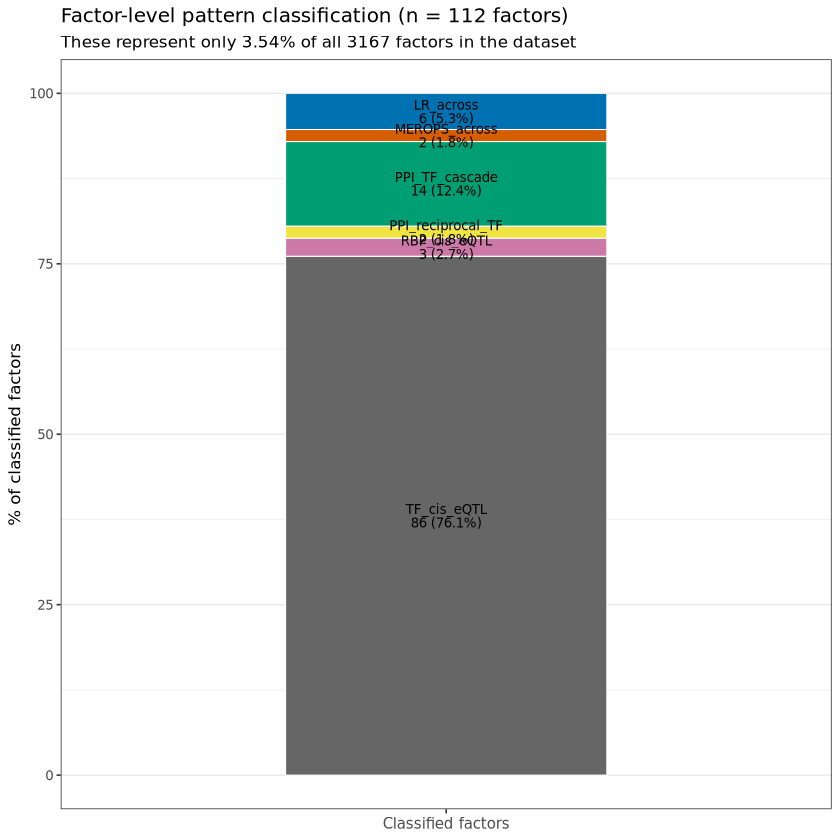

In [32]:
coverage_dir <- paste0(outdir, "coverage_summary/")
dir.create(coverage_dir, recursive = TRUE, showWarnings = FALSE)

factors_PPI_reciprocal <- unique(ppi_reciprocal_units[, .(Source_module, Source_gene, program)])
factors_PPI_reciprocal[, category := "PPI_reciprocal_TF"]

factors_PPI_cascade <- unique(cascade_positive_units[, .(Source_module, Source_gene, program)])
factors_PPI_cascade[, category := "PPI_TF_cascade"]

all_categorized_final <- rbindlist(list(factors_TF, factors_RBP, factors_LR, factors_MEROPS,
                                          factors_PPI_reciprocal, factors_PPI_cascade))

factor_category_counts_final <- all_categorized_final[, .(n_categories = uniqueN(category),
                                                             categories = paste(sort(unique(category)), collapse = ", ")),
                                                         by = .(Source_module, Source_gene, program)]
cat("Factors appearing in >1 category (should be empty if still mutually exclusive):\n")
print(factor_category_counts_final[n_categories > 1])

n_unique_categorized_final <- uniqueN(all_categorized_final[, .(Source_module, Source_gene, program)])
n_total_factors <- uniqueN(whole_eqtl_annotated[, .(Source_module, Source_gene, program)])
pct_of_all_factors <- round(100 * n_unique_categorized_final / n_total_factors, 2)

cat(sprintf("\nTotal unique factors classified across all 6 patterns: %d / %d (%.2f%%)\n",
            n_unique_categorized_final, n_total_factors, pct_of_all_factors))

pattern_counts <- all_categorized_final[, .N, by = category]
pattern_counts[, pct_of_classified := 100 * N / sum(N)]
print(pattern_counts)

pattern_palette_colors <- c(palettes$vibrant$blue, palettes$vibrant$vermillion, palettes$vibrant$green,
                             palettes$vibrant$yellow, palettes$vibrant$magenta, "grey40")
category_levels <- sort(unique(pattern_counts$category))
fill_values <- setNames(pattern_palette_colors[seq_along(category_levels)], category_levels)

p_factor_coverage <- ggplot(pattern_counts, aes(x = "Classified factors", y = pct_of_classified, fill = category)) +
  geom_col(width = 0.5, color = "white", linewidth = 0.3) +
  geom_text(aes(label = paste0(category, "\n", N, " (", round(pct_of_classified, 1), "%)")),
            position = position_stack(vjust = 0.5), size = 2.8, lineheight = 0.85) +
  scale_fill_manual(values = fill_values) +
  labs(
    title = paste0("Factor-level pattern classification (n = ", n_unique_categorized_final, " factors)"),
    subtitle = paste0("These represent only ", pct_of_all_factors, "% of all ", n_total_factors, " factors in the dataset"),
    x = NULL, y = "% of classified factors", fill = "Pattern"
  ) +
  theme_bw(base_size = 10) +
  theme(legend.position = "none", axis.text.x = element_text(size = 9),
        panel.grid.major.x = element_blank())

print(p_factor_coverage)

ggsave(paste0(coverage_dir, "factor_level_coverage.pdf"), p_factor_coverage, width = 5, height = 7)
ggsave(paste0(coverage_dir, "factor_level_coverage.png"), p_factor_coverage, width = 5, height = 7, dpi = 200)
ggsave(paste0(coverage_dir, "factor_level_coverage.svg"), p_factor_coverage, width = 5, height = 7)


## Edge-level coverage (non-stacked, log scale)

Edges with >=1 annotation: 3080 / 305496 (1.01%)
                                  label n_edges
                                 <fctr>   <int>
1: PPI (STRING_experimental >=0.1 <0.4)    1857
2:                    Source_TF->Target     422
3:                   Target_RBP->Source     286
4:      PPI (STRING_experimental >=0.4)     219
5:       Target_Ligand->Source_Receptor     140
6:                   Source_RBP->Target      90
7:                    Target_TF->Source      89
8:       Source_Ligand->Target_Receptor      14
9:   Target_Peptidase->Source_Substrate      11


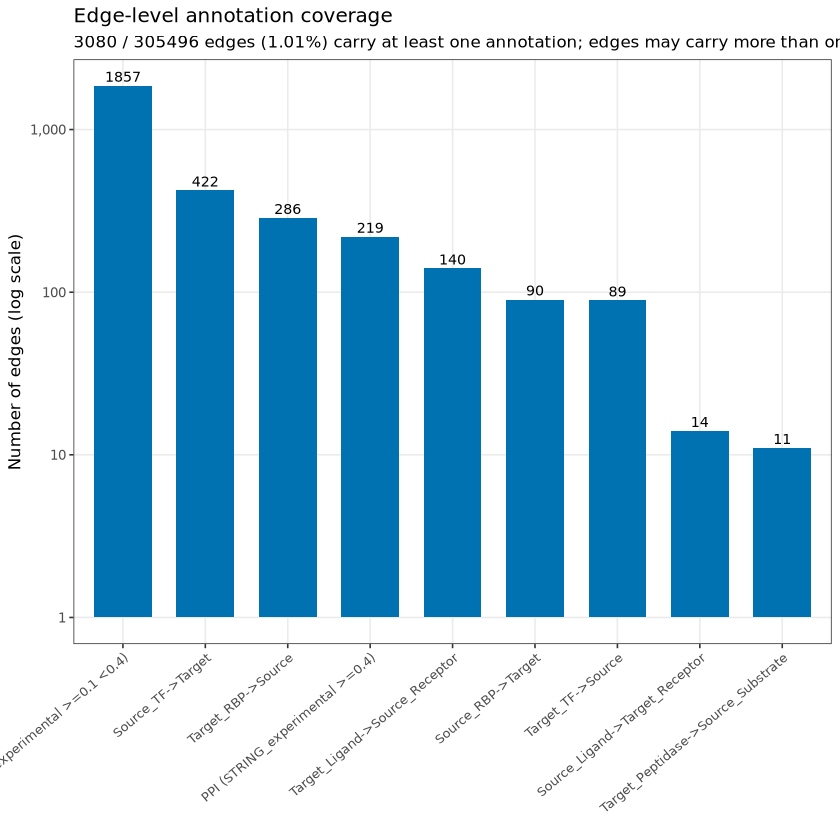

In [33]:
n_edges_total <- nrow(whole_eqtl_annotated)
edge_annot_counts <- sort(table(unlist(strsplit(whole_eqtl_annotated[!is.na(edge_role)]$edge_role, ";"))), decreasing = TRUE)

edge_label_dt <- data.table(
  label = names(edge_annot_counts),
  n_edges = as.integer(edge_annot_counts)
)
edge_label_dt[, label := factor(label, levels = label[order(-n_edges)])]

n_any_annotated <- sum(whole_eqtl_annotated$n_edge_roles > 0)
pct_any_annotated <- round(100 * n_any_annotated / n_edges_total, 2)

cat(sprintf("Edges with >=1 annotation: %d / %d (%.2f%%)\n", n_any_annotated, n_edges_total, pct_any_annotated))
print(edge_label_dt)

p_edge_coverage <- ggplot(edge_label_dt, aes(x = label, y = n_edges)) +
  geom_col(fill = palettes$vibrant$blue, width = 0.7) +
  geom_text(aes(label = n_edges), vjust = -0.4, size = 3) +
  scale_y_log10(labels = scales::label_comma()) +
  labs(
    title = "Edge-level annotation coverage",
    subtitle = paste0(n_any_annotated, " / ", n_edges_total, " edges (", pct_any_annotated,
                       "%) carry at least one annotation; edges may carry more than one label"),
    x = NULL, y = "Number of edges (log scale)"
  ) +
  theme_bw(base_size = 10) +
  theme(axis.text.x = element_text(angle = 40, hjust = 1, size = 8),
        panel.grid.minor = element_blank())

print(p_edge_coverage)

ggsave(paste0(coverage_dir, "edge_level_coverage.pdf"), p_edge_coverage, width = 8, height = 6)
ggsave(paste0(coverage_dir, "edge_level_coverage.png"), p_edge_coverage, width = 8, height = 6, dpi = 200)
ggsave(paste0(coverage_dir, "edge_level_coverage.svg"), p_edge_coverage, width = 8, height = 6)
